Exploratory Data Analysis (EDA)

I explore the Automobile (cars) dataset to understand the data so I can predict vehicle price.

The goal of this notebook is to:

-understand the data

-identify its features

-visualize relationships between variables

Loading/inspecting the Data:

I load the data to see what it looks like as well as label the columns so I can inspect the variables.



In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/raw/imports-85.data", header=None, na_values="?")
df.shape


(205, 26)

In [2]:
column_names = ["symboling","normalized_losses","make","fuel_type","aspiration","num_doors","body_style","drive_wheels","engine_location","wheel_base","length","width","height","curb_weight","engine_type","num_cylinders","engine_size","fuel_system","bore", "stroke","compression ratio", "horsepower","peak_rpm","city_mpg","highway_mpg","price"]
df.columns = column_names

In [23]:
df.head()

,symboling,normalized_losses,make,fuel_type,aspiration,num_doors,body_style,drive_wheels,engine_location,wheel_base,...,engine_size,fuel_system,bore,stroke,compression ratio,horsepower,peak_rpm,city_mpg,highway_mpg,price
0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495.0
1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500.0
2,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500.0
3,2,164.0,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950.0
4,2,164.0,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450.0


In [3]:
df.shape, df.columns[:10]

((205, 26),
 Index(['symboling', 'normalized_losses', 'make', 'fuel_type', 'aspiration',
        'num_doors', 'body_style', 'drive_wheels', 'engine_location',
        'wheel_base'],
       dtype='object'))

In [4]:
df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          205 non-null    int64  
 1   normalized_losses  164 non-null    float64
 2   make               205 non-null    object 
 3   fuel_type          205 non-null    object 
 4   aspiration         205 non-null    object 
 5   num_doors          203 non-null    object 
 6   body_style         205 non-null    object 
 7   drive_wheels       205 non-null    object 
 8   engine_location    205 non-null    object 
 9   wheel_base         205 non-null    float64
 10  length             205 non-null    float64
 11  width              205 non-null    float64
 12  height             205 non-null    float64
 13  curb_weight        205 non-null    int64  
 14  engine_type        205 non-null    object 
 15  num_cylinders      205 non-null    object 
 16  engine_size        205 non

Summary of stats:

I examine the stats of the variables to provide an overview of range, mean and distribution.

In [5]:
df["price"].describe(include="all")

count      201.000000
mean     13207.129353
std       7947.066342
min       5118.000000
25%       7775.000000
50%      10295.000000
75%      16500.000000
max      45400.000000
Name: price, dtype: float64

In [6]:
df.isna().sum()

symboling             0
normalized_losses    41
make                  0
fuel_type             0
aspiration            0
num_doors             2
body_style            0
drive_wheels          0
engine_location       0
wheel_base            0
length                0
width                 0
height                0
curb_weight           0
engine_type           0
num_cylinders         0
engine_size           0
fuel_system           0
bore                  4
stroke                4
compression ratio     0
horsepower            2
peak_rpm              2
city_mpg              0
highway_mpg           0
price                 4
dtype: int64

In [7]:
(df== "?").sum()

symboling            0
normalized_losses    0
make                 0
fuel_type            0
aspiration           0
num_doors            0
body_style           0
drive_wheels         0
engine_location      0
wheel_base           0
length               0
width                0
height               0
curb_weight          0
engine_type          0
num_cylinders        0
engine_size          0
fuel_system          0
bore                 0
stroke               0
compression ratio    0
horsepower           0
peak_rpm             0
city_mpg             0
highway_mpg          0
price                0
dtype: int64

Exploring relationships between variables:

I wanted to see how different variables relate to car price. engine_size, curb_weight, and horsepower have the best correlations that can be plotted.

In [8]:
df.corr(numeric_only=True)["price"].sort_values(ascending=False)

price                1.000000
engine_size          0.872335
curb_weight          0.834415
horsepower           0.810533
width                0.751265
length               0.690628
wheel_base           0.584642
bore                 0.543436
normalized_losses    0.203254
height               0.135486
stroke               0.082310
compression ratio    0.071107
symboling           -0.082391
peak_rpm            -0.101649
city_mpg            -0.686571
highway_mpg         -0.704692
Name: price, dtype: float64

Thoughts:

Despite engine_size, horsepower, and curb_weight having the highest correlation, when plotted, curb_weight has the highest homoscedascity. Heavier vehicles tend to cost more than lighter ones. curb_weight will probably be the best to use for linear regression modeling later on in the project.

<Axes: xlabel='engine_size', ylabel='price'>

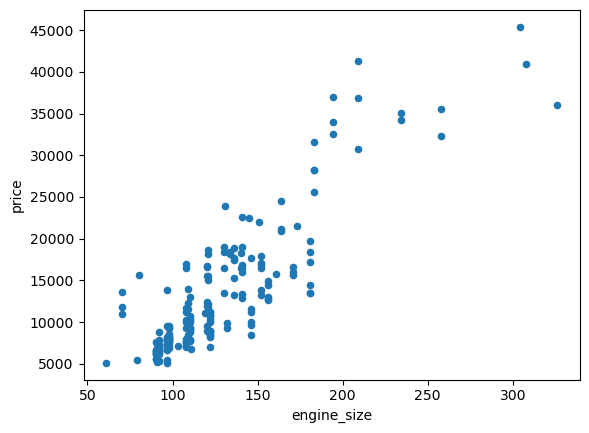

In [9]:
df.plot.scatter(x="engine_size", y="price")

<Axes: xlabel='curb_weight', ylabel='price'>

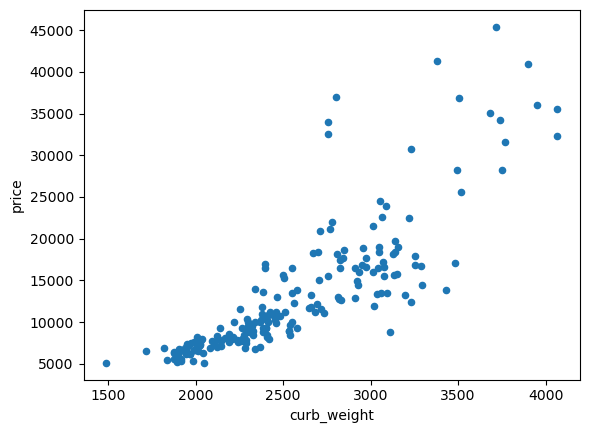

In [10]:
df.plot.scatter(x="curb_weight", y="price")

<Axes: xlabel='horsepower', ylabel='price'>

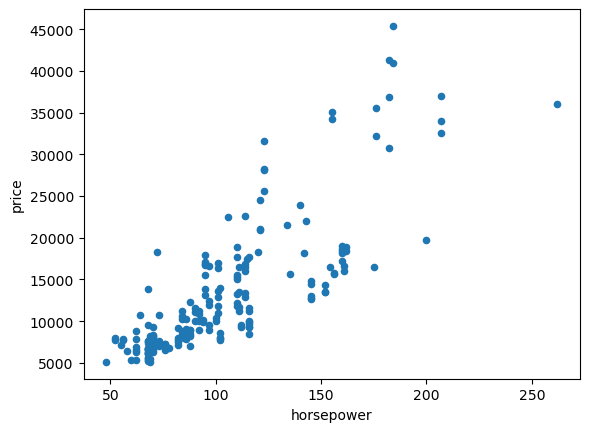

In [11]:
df.plot.scatter(x="horsepower", y="price")

Some things I learned from EDA:

-Engine size, horsepower, and curb weight show the strongest correlations with price

-Scatter plotting these three variables showed a roughly linear relationship between them and price

-Among these three variables, curb weight visually looks like it has the most consistent relationship with price.

Additional considerations:

What about sports cars? They are low weight and high horsepower (possibly higher engine size). Sports cars break the "more weight/higher cost" rule. I'd like to explore this further if i had more time.

Average Price by Manufacturer:

This chart shows the average vehicle price grouped by the manufacturers that made them. Jaguar, Mercedes, Porsche, BMW are more high end while chevy, dodge, plymouth, and honda are more economy brands.

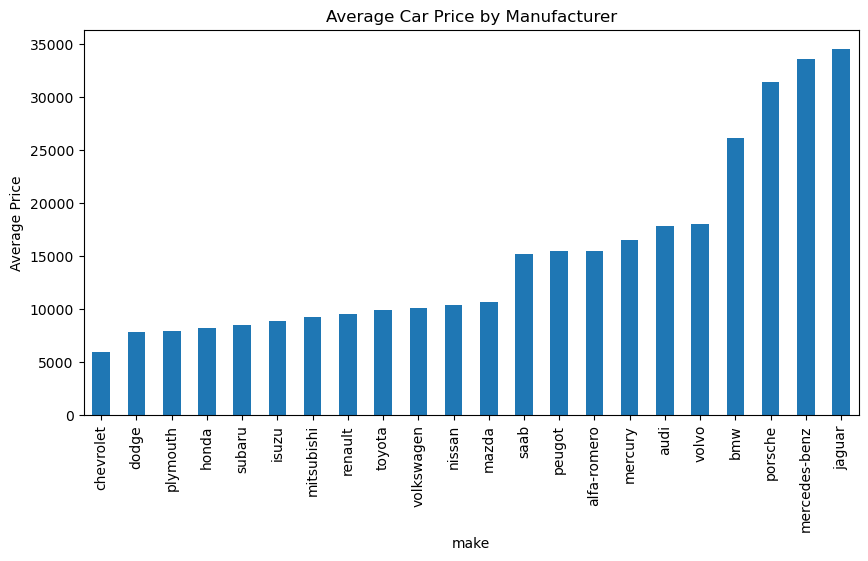

In [31]:
df.groupby("make")["price"].mean().sort_values().plot(kind = "bar", figsize=(10,5))
plt.ylabel("Average Price")
plt.title("Average Car Price by Manufacturer")
plt.show()